STARR FROM THE BEGINING...I DONT KNOW WHAT WILL HAPPEN 

objective---

1-Complete structure, ready to be directly copied and run in a Jupyter Notebook

2-Includes both ViT and ResNet（One Notebook；Two Models；The Same Dataset；The Same Training Loop--Control variables:
Same Dataset
Same Split 
Same Loss 
Same Optimizer 
Same Epoch ）

3-Fully aligned with the regression objective outlined in your PDF

4-Freezes the backbone, training only the regression head

In [291]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter

In [292]:
data_dir = "dataset"

image_paths = []
labels = []

level_mapping = {
    "LEV1-Conservative_change": 0.0,
    "LEV2-Partially_change": 0.25,
    "LEV3-Completely_change_into_specific_items": 0.5,
    "LEV4-Almost_abstract_shape_with_a_bit_inherent_feature": 0.75,
    "LEV5-Completely_abstract": 1.0
}

for folder_name in level_mapping:
    folder_path = os.path.join(data_dir, folder_name)

    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder_path, file_name))
            labels.append(1-level_mapping[folder_name])  # 反转

print("Distribution:", Counter(labels))

Distribution: Counter({0.75: 124, 0.25: 104, 0.5: 47, 1.0: 24, 0.0: 15})


In [293]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42
)

In [294]:
class CatDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label

In [295]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = CatDataset(train_paths, train_labels, transform)
val_dataset = CatDataset(val_paths, val_labels, transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [296]:
class ResNetRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "resnet50",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return torch.sigmoid(output)

In [297]:
class ViTRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0
        )

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.regressor = nn.Linear(self.backbone.num_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        output = self.regressor(features)
        return torch.sigmoid(output)

In [298]:
def train_model(model, train_loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader):.4f}")

    return model

In [299]:
def collect_predictions(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            outputs = model(images)
            preds.extend(outputs.cpu().numpy().flatten())
            labels.extend(target.numpy())

    return np.array(preds), np.array(labels)

In [300]:
resnet_model = ResNetRegression()
vit_model = ViTRegression()

print("Training ResNet...")
resnet_model = train_model(resnet_model, train_loader, epochs=7)

print("\nTraining ViT...")
vit_model = train_model(vit_model, train_loader, epochs=7)

Training ResNet...
Epoch 1, Loss: 0.0765
Epoch 2, Loss: 0.0693
Epoch 3, Loss: 0.0630
Epoch 4, Loss: 0.0581
Epoch 5, Loss: 0.0545
Epoch 6, Loss: 0.0520
Epoch 7, Loss: 0.0478

Training ViT...
Epoch 1, Loss: 0.0914
Epoch 2, Loss: 0.0536
Epoch 3, Loss: 0.0389
Epoch 4, Loss: 0.0296
Epoch 5, Loss: 0.0274
Epoch 6, Loss: 0.0231
Epoch 7, Loss: 0.0194


In [301]:
res_preds, res_labels = collect_predictions(resnet_model, val_loader)
vit_preds, vit_labels = collect_predictions(vit_model, val_loader)

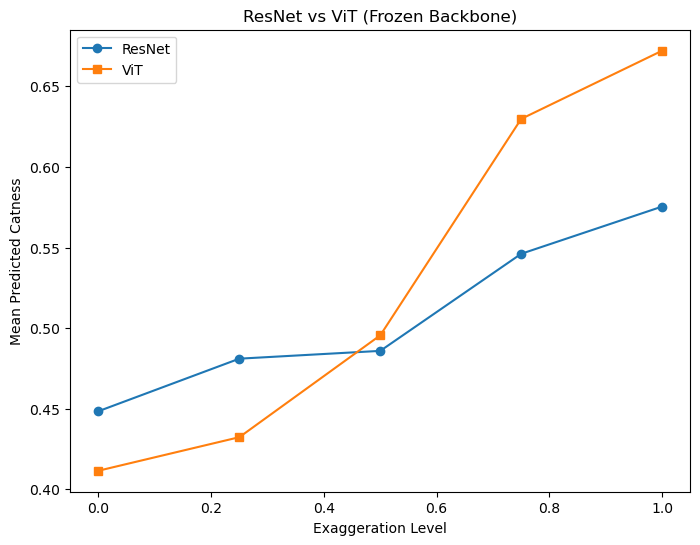

In [302]:
levels = sorted(set(res_labels))

res_means = []
vit_means = []

for l in levels:
    res_means.append(res_preds[res_labels == l].mean())
    vit_means.append(vit_preds[vit_labels == l].mean())

plt.figure(figsize=(8,6))
plt.plot(levels, res_means, marker='o', label="ResNet")
plt.plot(levels, vit_means, marker='s', label="ViT")

plt.xlabel("Exaggeration Level")
plt.ylabel("Mean Predicted Catness")
plt.title("ResNet vs ViT (Frozen Backbone)")
plt.legend()
plt.show()

In [303]:
def collect_predictions(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():
        for images, target in loader:
            images = images.to(device)
            outputs = model(images)
            preds.extend(outputs.cpu().numpy().flatten())
            labels.extend(target.numpy())

    return np.array(preds), np.array(labels)

In [304]:
print("ResNet Correlation:",
      np.corrcoef(levels, res_means)[0,1])

print("ViT Correlation:",
      np.corrcoef(levels, vit_means)[0,1])

ResNet Correlation: 0.9725919757668217
ViT Correlation: 0.9698670828892599
